# (연구) HST example 1
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [기하학적 딥러닝, 논문연구]

In [77]:
import heavysnow as hs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybase as pb
import plotnine as p9
import rpy2 
%load_ext rpy2.ipython

In [78]:
f=np.array([-1,-1,-1,1,-1,-1,-1,1,1,1,-1,1,1,1])*1.0
n=len(f)
V=list(range(n))
W=np.zeros([n,n])
for i in range(n):
    for j in range(n):
        if abs(i-j)==1: W[i,j]=1
W[0,0]=0.5
W[n-1,n-1]=0.5

In [73]:
gs1=hs.GraphSignal(V,W,f)

In [4]:
hst1=hs.HeavySnowTransform(gs1)
hst2=hs.HeavySnowTransform(gs1)
hst3=hs.HeavySnowTransform(gs1)
hst4=hs.HeavySnowTransform(gs1)
hst5=hs.HeavySnowTransform(gs1)
hst6=hs.HeavySnowTransform(gs1)
hst7=hs.HeavySnowTransform(gs1)
hst8=hs.HeavySnowTransform(gs1)

hst1.snow(tau=10,b=0.03)
hst2.snow(tau=50,b=0.03)
hst3.snow(tau=100,b=0.03)
hst4.snow(tau=500,b=0.03)
hst5.snow(tau=1000,b=0.03)
hst6.snow(tau=5000,b=0.03)
hst7.snow(tau=10000,b=0.03)
hst8.snow(tau=50000,b=0.03)

HST (tau= 10, b=0.03)
10/10
HST completed and all history is recorded.
HST (tau= 50, b=0.03)
50/50
HST completed and all history is recorded.
HST (tau= 100, b=0.03)
100/100
HST completed and all history is recorded.
HST (tau= 500, b=0.03)
500/500
HST completed and all history is recorded.
HST (tau= 1000, b=0.03)
1000/1000
HST completed and all history is recorded.
HST (tau= 5000, b=0.03)
5000/5000
HST completed and all history is recorded.
HST (tau= 10000, b=0.03)
10000/10000
HST completed and all history is recorded.
HST (tau= 50000, b=0.03)
50000/50000
HST completed and all history is recorded.


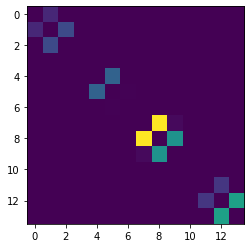

In [74]:
plt.imshow(hst7.snowweight)

In [75]:
pb.push(hst7.tau,"maxtau")
pb.push(hst7.graphweight,"W_Graph")
pb.push(hst7.euclidweight,"W_Euclid")
pb.push(hst7.snowweight,"W_HST")
pb.push(hst7.V,"V")
pb.push(hst7.f,"f")
pb.push(hst7.n,"n")

In [96]:
%%R 
library(tidyverse)
library(latex2exp)
library(gridExtra)
Vtext=str_c('node ',V+1)
p0<-ggplot(data=tibble(V=V,f=f,Vtext=Vtext),aes(x=V,y=f,label=Vtext))+
geom_col(aes(fill=(f>0)),width=0.1)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
geom_text(fontface = 4,size=8)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.2,1.2)+
theme(plot.title=element_text(face="bold.italic"))
#ggsave(plot=p0,"./fig/2021-0217_fig0.pdf",width=20,height=6)

In [97]:
%%R
grid<-expand.grid(x=1:n,y=1:n)
W_Graph_long<-as_tibble(cbind(grid,as.vector(W_Graph)));names(W_Graph_long)<-c("x","y","W")
W_Euclid_long<-as_tibble(cbind(grid,as.vector(W_Euclid)));names(W_Euclid_long)<-c("x","y","W")
W_HST_long<-as_tibble(cbind(grid,as.vector(W_HST)));names(W_HST_long)<-c("x","y","W")

TableGrob (1 x 3) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (1-1,2-2) arrange gtable[layout]
3 3 (1-1,3-3) arrange gtable[layout]


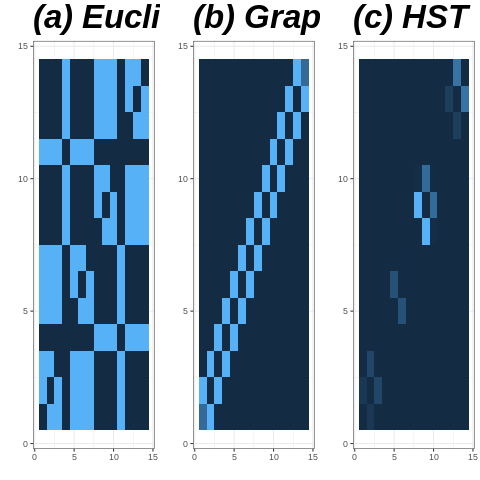

In [98]:
%%R
p1_a<-ggplot()+geom_tile(data=W_Euclid_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
#scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.25,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$W$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(a) Euclid")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

p1_b<-ggplot()+geom_tile(data=W_Graph_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
#scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(b) Graph")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

p1_c<-ggplot()+geom_tile(data=W_HST_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
#scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}(\\tau)$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(c) HST")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

p1<-grid.arrange(p1_a,p1_b,p1_c,ncol=3)
#ggsave(plot=p1,"./fig/2021-0514_fig1.pdf",width=20,height=4)
p1